# DATA-445: Homework Assignment 4

**Instructions**

- This homework assignment is worth **119** points.
- Please submit a **.ipynb** file to Blackboard.
- **Please strive for clarity and organization.**
- **AI usage**:
  - AI use is strictly **prohibited** for conceptual exercises.
  - For applied (Python) exercises, you may use AI exclusively for **debugging**. Do not use AI to generate answers.
- **Due Date: October 2, 2026, by 11:59 PM.**

## Exercise 1

(5 points) What is a perceptron? Be specific.

A perceptron is bascially a simple verison of a nueral network. It takes inputs and gives each one a weight based on how important it is. Then it adds bias and this helps move the decision boundary. After that it passes its result through an activation function which in turn produces a prediction.

## Exercise 2

(5 points) What are the different types of perceptrons? Briefly describe each of them.

There are two types of perceptrons.
The first is Single-Layer Perceptron: This is the simple yes or no decision maker, as defined in the question above.
The second is Multi-Layer Perceptron: This has one or more hidden layers, can learn nonlinear realtions, can do both classification and regression, and uses ReLU, Sigmoid, or Tanh. This allows it to solve problems that a single perceptron can't.

## Exercise 3

(5 points) What is a hard margin in a support vector machine model? Be specific.

A hard margin in a support vector forces every point to be classified correctly, no points are allowed to be inside the margin, and it tries to make the margin as wide as possible. 
The points closest to the decision boundary are the support vectors.

## Exercise 4

(4 points) The effectiveness of a support vector machine model depends on:

(a) kernel  
(b) kernel parameters  
(c) penalty cost parameter  
(d) All of the above  
(e) None of the above

I think the answer is (d) all of the above because a svm's effectiveness depends on the kernal, kernal parameters, and penalty cost parameters.

## Exercise 5

(4 points) What is/are **true** about kernel in SVM?

(a) Kernel function map low dimensional data into high dimensional space.  
(b) Kernel function map high dimensional data into low dimensional space.  
(c) It is a similarity function.  
(d) (a) and (c)  
(e) (b) and (c)  
(f) (a), (b) and (c)  
(g) None of the above

I think the answer is (d) (a) and (c) because a kernal allows svm to work as if it mapped data from a lower dinmensional space to a higher one and a kernal function measures similarity between data points.

## Exercise 6

(4 points) Which of the following statements is **true** regarding the role of the activation function in the hidden layer(s) of a multi-layer perceptron (MLP)?

(a) It has no effect on the model's ability to learn non-linear patterns.  
(b) It allows the network to learn and approximate non-linear decision boundaries.  
(c) It is only necessary in the output layer, not in the hidden layer(s).  
(d) It converts the MLP into a linear model, regardless of the number of hidden layers.  
(e) None of the above.

I think the answer is (b) because nonlinear activation functions ReLU, Sigmoid, and Tanh allow a MLP to learn complex nonlinear relationships. 

## Exercise 7

(5 points) What is a **soft margin** in a support vector machine model? How does the penalty (cost) parameter $C$ affect the trade-off between the width of the margin and the number of misclassified observations? Be specific.

unlike the hard margin a soft margin svm allows some observation to be inside the margin or even to be misclassified instead of requiring them all to be perfectly separated. 
A large C strongly penalizes mislcassified observations while a small C gives more tolerance for the misclassified observations.

## Exercise 8

Consider the `framingham.csv` data file. The dataset is publically available on the Kaggle website, and it is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts. The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD). The dataset provides the patients' information. It includes over 4,000 records and 15 attributes. Each attribute is a potential risk factor. There are both demographic, behavioral and medical risk factors.

- **Demographic**:
  - Sex: male or female (Nominal)
  - Age: Age of the patient (Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)

- **Behavioral**
  - Current Smoker: whether or not the patient is a current smoker (Nominal)
  - Cigs Per Day: the number of cigarettes that the person smoked on average in one day (can be considered continuous as one can have any number of cigarettes, even half a cigarette)

- **Medical (history)**
  - BP Meds: whether or not the patient was on blood pressure medication (Nominal)
  - Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
  - Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
  - Diabetes: whether or not the patient had diabetes (Nominal)

- **Medical (current)**
  - Tot Chol: total cholesterol level (Continuous)
  - Sys BP: systolic blood pressure (Continuous)
  - Dia BP: diastolic blood pressure (Continuous)
  - BMI: Body Mass Index (Continuous)
  - Heart Rate: heart rate (Continuous - In medical research, variables such as heart rate though in fact discrete, yet are considered continuous because of large number of possible values.)
  - Glucose: glucose level (Continuous)

- **Predict variable (desired target)**
  - 10 year risk of coronary heart disease CHD (binary: "1", means "Yes", "0" means "No")

**In Python**, answer the following:

### (a)

(4 points) Using the `pandas` library, read the csv data file and create a data-frame called `heart`.

In [2]:
import pandas as pd

heart = pd.read_csv('framingham.csv')
heart.head()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


### (b)

(3 points) Remove observations with missing values.

In [3]:
heart = heart.dropna()

### (c)

(60 points) Using `age`, `currentSmoker`, `totChol`, `BMI`, and `heartRate` as the predictor variables, and `TenYearCHD` as the target variable, do the following:

#### (i)

Set up a 5-fold cross-validation splitter (e.g., `StratifiedKFold` with `n_splits = 5`) on the predictor and target variables, and generate the `train`/`validation` indices for each of the 5 folds.

In [5]:
from sklearn.model_selection import StratifiedKFold

X = heart[['age', 'currentSmoker', 'totChol', 'BMI', 'heartRate']]
y = heart['TenYearCHD']

skf = StratifiedKFold(n_splits=5)

for train_index, val_index in skf.split(X, y):
    print("TRAIN indices:", train_index, "VALIDATION indices:", val_index)

TRAIN indices: [ 672  674  679 ... 3653 3654 3655] VALIDATION indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 

#### (ii)

Using `MinMaxScaler`, transform the input variables of each fold's `train` and `validation` sets to 0-1 scale. This scaling must be applied independently within each fold, before building any of the models below.

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

for train_index, val_index in skf.split(X, y):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    print("Scaled TRAIN data:", X_train_scaled)
    print("Scaled VALIDATION data:", X_val_scaled)

Scaled TRAIN data: [[0.81578947 0.         0.19917864 0.19711068 0.32323232]
 [0.34210526 0.         0.30595483 0.15254652 0.32323232]
 [0.07894737 1.         0.12731006 0.124143   0.29292929]
 ...
 [0.47368421 1.         0.41067762 0.24510284 0.22222222]
 [0.5        1.         0.19301848 0.09182174 0.21212121]
 [0.52631579 0.         0.32032854 0.13491675 0.36363636]]
Scaled VALIDATION data: [[0.18421053 0.         0.16837782 0.26958864 0.36363636]
 [0.36842105 0.         0.28131417 0.31268364 0.51515152]
 [0.42105263 1.         0.27104723 0.22967679 0.31313131]
 ...
 [0.71052632 1.         0.26078029 0.23114594 0.44444444]
 [0.42105263 0.         0.24229979 0.12683643 0.26262626]
 [0.31578947 0.         0.31827515 0.37218413 0.31313131]]
Scaled TRAIN data: [[0.18421053 0.         0.23361823 0.27702375 0.35714286]
 [0.36842105 0.         0.39031339 0.31968008 0.51020408]
 [0.42105263 1.         0.37606838 0.23751818 0.30612245]
 ...
 [0.47368421 1.         0.56980057 0.2527872  0.214

**Model 1**: Using 5-fold cross-validation, build a multi-layer perceptron model with one single hidden layer with 4 neurons (hyperbolic tangent as the activation function) on each fold. Use the stochastic descent gradient as the method to estimate the weights (`solver = 'sgd'`). Use `max_iter = 1000` and `batch_size = 500` to build the model. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import recall_score

recall_scores_tanh = []

for train_index, val_index in skf.split(X, y):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    model = MLPClassifier(hidden_layer_sizes=(4,), activation='tanh', solver='sgd', max_iter=1000, batch_size=500)
    model.fit(X_train_scaled, y_train)
    
    y_val_pred_prob = model.predict_proba(X_val_scaled)[:, 1]
    y_val_pred = (y_val_pred_prob >= 0.15).astype(int)
    
    recall = recall_score(y_val, y_val_pred)
    recall_scores_tanh.append(recall)

print("Recall scores for each fold:", recall_scores_tanh)


Recall scores for each fold: [0.5714285714285714, 0.45045045045045046, 0.38738738738738737, 0.43243243243243246, 0.6875]


**Model 2**: Using 5-fold cross-validation, build a multi-layer perceptron model with one single hidden layer with 4 neurons (ReLU as the activation function) on each fold. Use the stochastic descent gradient as the method to estimate the weights (`solver = 'sgd'`). Use `max_iter = 1000` and `batch_size = 500` to build the model. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [10]:
recall_scores_relu = []

for train_index, val_index in skf.split(X, y):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    model_relu = MLPClassifier(hidden_layer_sizes=(4,), activation='relu', solver='sgd', max_iter=1000, batch_size=500)
    model_relu.fit(X_train_scaled, y_train)
    
    y_val_pred_prob_relu = model_relu.predict_proba(X_val_scaled)[:, 1]
    y_val_pred_relu = (y_val_pred_prob_relu >= 0.15).astype(int)
    
    recall_relu = recall_score(y_val, y_val_pred_relu)
    recall_scores_relu.append(recall_relu)

print("Recall scores for each fold (ReLU):", recall_scores_relu)

Recall scores for each fold (ReLU): [0.5267857142857143, 0.6756756756756757, 0.5855855855855856, 1.0, 1.0]


**Model 3**: Using 5-fold cross-validation, build a support vector machine model using `rbf` as the kernel on each fold. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [11]:
from sklearn.svm import SVC

recall_scores_svm = []

for train_index, val_index in skf.split(X, y):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    model_svm = SVC(kernel='rbf', probability=True)
    model_svm.fit(X_train_scaled, y_train)
    
    y_val_pred_prob_svm = model_svm.predict_proba(X_val_scaled)[:, 1]
    y_val_pred_svm = (y_val_pred_prob_svm >= 0.15).astype(int)
    
    recall_svm = recall_score(y_val, y_val_pred_svm)
    recall_scores_svm.append(recall_svm)

print("Recall scores for each fold (SVM with RBF kernel):", recall_scores_svm)

Recall scores for each fold (SVM with RBF kernel): [0.5357142857142857, 0.9099099099099099, 0.6666666666666666, 0.6486486486486487, 0.6428571428571429]


**Model 4**: Using 5-fold cross-validation, build a support vector machine model using `poly` as the kernel on each fold. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [12]:
recall_scores_poly = []

for train_index, val_index in skf.split(X, y):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    model_poly = SVC(kernel='poly', probability=True)
    model_poly.fit(X_train_scaled, y_train)
    
    y_val_pred_prob_poly = model_poly.predict_proba(X_val_scaled)[:, 1]
    y_val_pred_poly = (y_val_pred_prob_poly >= 0.15).astype(int)
    
    recall_poly = recall_score(y_val, y_val_pred_poly)
    recall_scores_poly.append(recall_poly)

print("Recall scores for each fold (SVM with Poly kernel):", recall_scores_poly)

Recall scores for each fold (SVM with Poly kernel): [0.6696428571428571, 0.990990990990991, 0.7207207207207207, 1.0, 0.49107142857142855]


**Model 5**: Using 5-fold cross-validation, build a Random Forest model on each fold. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [13]:
from sklearn.ensemble import RandomForestClassifier

recall_scores_rf = []

for train_index, val_index in skf.split(X, y):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    model_rf = RandomForestClassifier()
    model_rf.fit(X_train_scaled, y_train)
    
    y_val_pred_prob_rf = model_rf.predict_proba(X_val_scaled)[:, 1]
    y_val_pred_rf = (y_val_pred_prob_rf >= 0.15).astype(int)
    
    recall_rf = recall_score(y_val, y_val_pred_rf)
    recall_scores_rf.append(recall_rf)

print("Recall scores for each fold (Random Forest):", recall_scores_rf)

Recall scores for each fold (Random Forest): [0.6339285714285714, 0.6036036036036037, 0.6036036036036037, 0.5675675675675675, 0.6160714285714286]


**Model 6**: Using 5-fold cross-validation, build an Extra Trees model on each fold. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [14]:
from sklearn.ensemble import ExtraTreesClassifier

recall_scores_et = []

for train_index, val_index in skf.split(X, y):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    model_et = ExtraTreesClassifier()
    model_et.fit(X_train_scaled, y_train)
    
    y_val_pred_prob_et = model_et.predict_proba(X_val_scaled)[:, 1]
    y_val_pred_et = (y_val_pred_prob_et >= 0.15).astype(int)
    
    recall_et = recall_score(y_val, y_val_pred_et)
    recall_scores_et.append(recall_et)

print("Recall scores for each fold (Extra Trees):", recall_scores_et)

Recall scores for each fold (Extra Trees): [0.5982142857142857, 0.5135135135135135, 0.5945945945945946, 0.5135135135135135, 0.625]


### (d)

(20 points) Using the recall values obtained in part (c), create a visualization that shows the recall value for each of the models at each fold. Also, report the average recall of each of the models across the 5 folds. What model would you use to predict `TenYearCHD`?

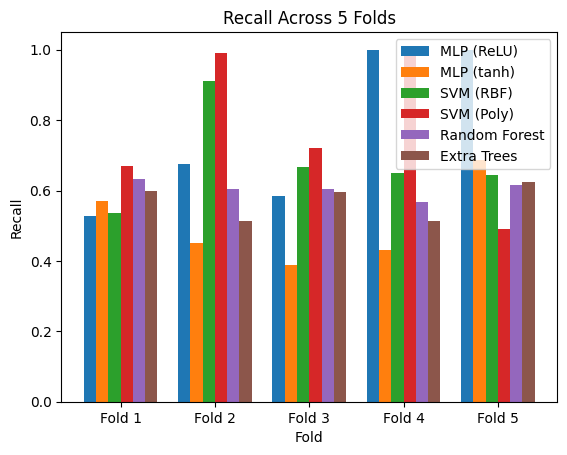

Average recall for MLP (ReLU): 0.76
Average recall for MLP (tanh): 0.51
Average recall for SVM (RBF): 0.68
Average recall for SVM (Poly): 0.77
Average recall for Random Forest: 0.60
Average recall for Extra Trees: 0.57


In [17]:
import numpy as np
import matplotlib.pyplot as plt

models = ['MLP (ReLU)', 'MLP (tanh)', 'SVM (RBF)', 'SVM (Poly)', 'Random Forest', 'Extra Trees']

recall_values = [
    recall_scores_relu,
    recall_scores_tanh,
    recall_scores_svm,
    recall_scores_poly,
    recall_scores_rf,
    recall_scores_et
]

average_recalls = [np.mean(recall) for recall in recall_values]

x = np.arange(5)
width = 0.13

fig, ax = plt.subplots()

for i, recall in enumerate(recall_values):
    ax.bar(x + i * width, recall, width, label=models[i])

ax.set_xlabel('Fold')
ax.set_ylabel('Recall')
ax.set_title('Recall Across 5 Folds')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5'])
ax.legend()

plt.show()

for model, avg in zip(models, average_recalls):
    print(f'Average recall for {model}: {avg:.2f}')

based on the average recall output Poly SVM just beats out ReLU for the best average recall so that is the best model to pick.